In [1]:
import numpy as np
import pandas as pd
import zarr
import os
import matplotlib.pyplot as plt
plt.style.use('../libs/my_style.mplstyle')

OUTPUT_PATH = "/Users/sasakinozomu/code/MTCargo_analysis/notebooks/figures"

path0 = "/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp"
path1 = "/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp001"
path2 = "/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp002"
path3 = '/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/beads_trans_crop_crop'
path4 = '/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/exp_crop1'

LPs_woB = []
LP5s = []

GPs = []

for p in [path0, path1, path2, path3, path4]:
    track_path = os.path.join(p, "roi_polar_x1000_y1000_w45_h45.csv")
    tracks = pd.read_csv(track_path)
    LPs_woB.extend(tracks['P'].values)

    track_path = os.path.join(p, "beads_tracks_with_local_P_rec5_new.csv")
    tracks = pd.read_csv(track_path)
    LP5s.extend(tracks['local_P'].values)

    globalP = os.path.join(p, "green_globalP.zarr")
    GP_array = zarr.open_array(globalP, mode='r')
    GPs.extend(GP_array[:])

Text(0, 0.5, 'Density')

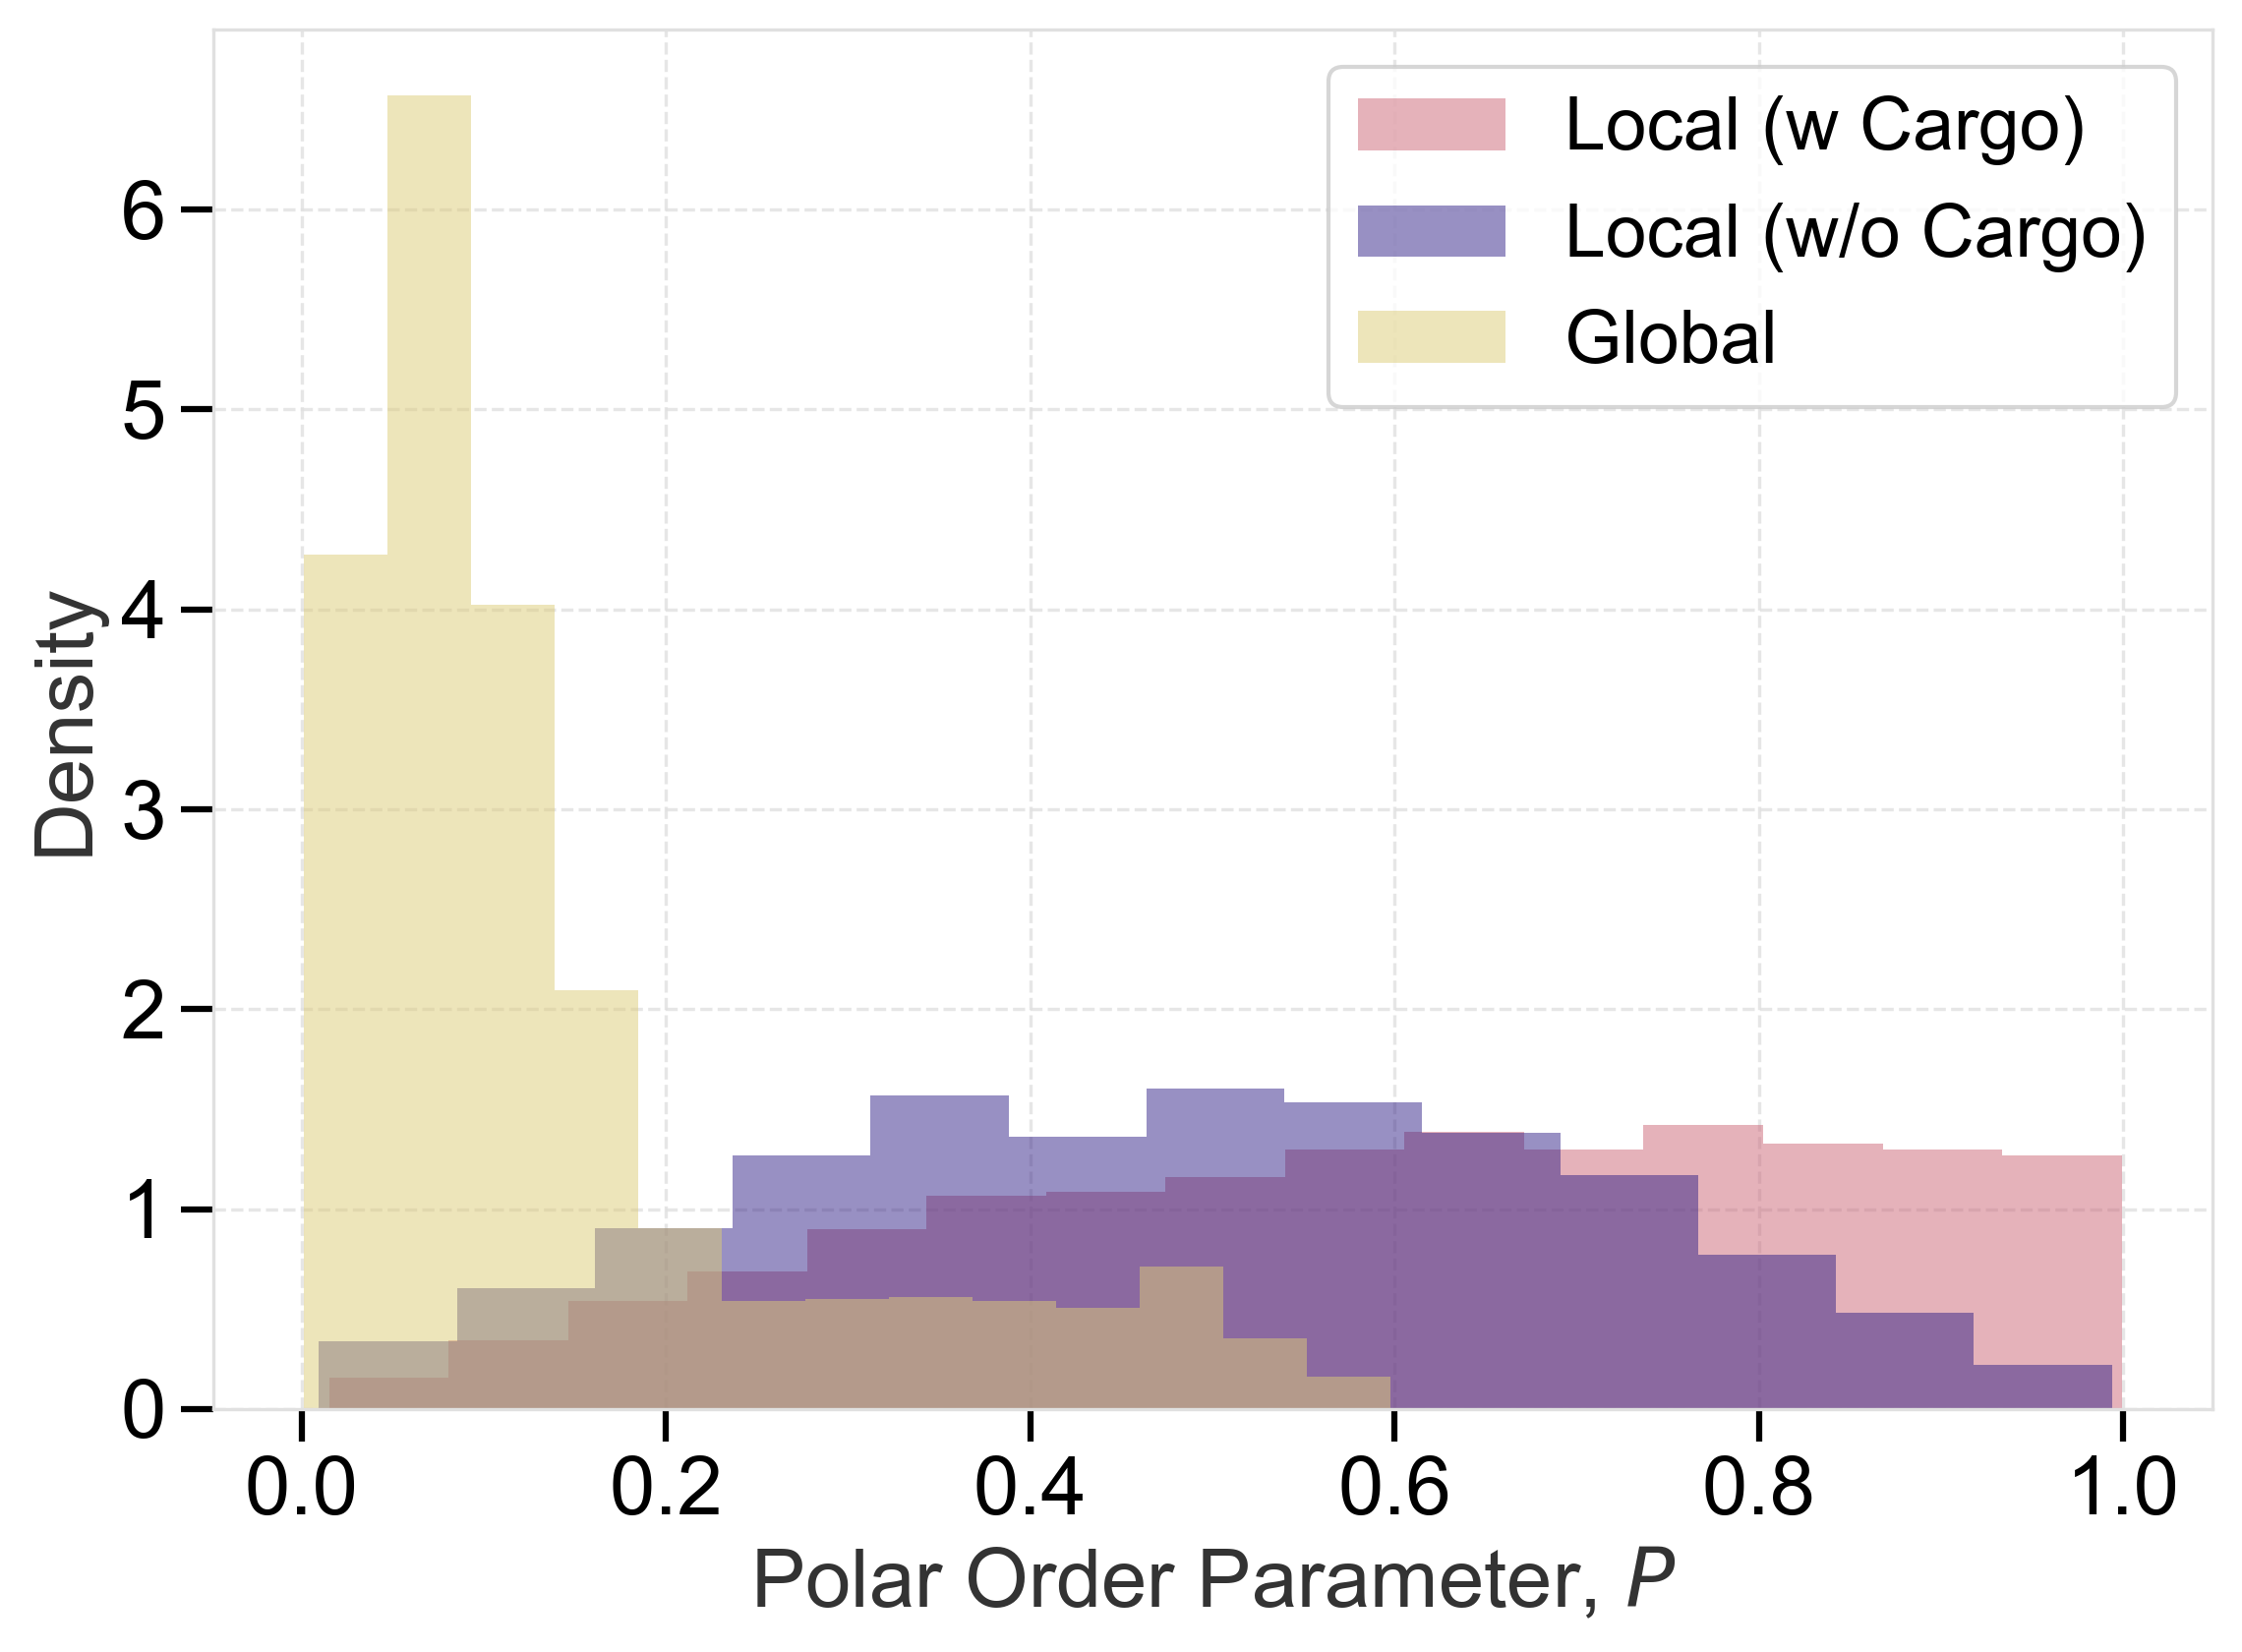

In [2]:
LPs_woB_array = np.array(LPs_woB)
LP5s_array = np.array(LP5s)
GPs_array = np.array(GPs)
# Nanを除去
LPs_woB_array = LPs_woB_array[~np.isnan(LPs_woB_array)]
LP5s_array = LP5s_array[~np.isnan(LP5s_array)]
GPs_array = GPs_array[~np.isnan(GPs_array)]

L_woB_bins = np.histogram_bin_edges(LPs_woB_array, bins='sturges')
LP5s_bins = np.histogram_bin_edges(LP5s_array, bins='sturges')
Gbins = np.histogram_bin_edges(GPs_array, bins='sturges')

fig, ax = plt.subplots()

ax.hist(LP5s_array, bins=LP5s_bins, alpha=0.5, label='Local (w Cargo)', density=True)
ax.hist(LPs_woB_array, bins=L_woB_bins, alpha=0.5, label='Local (w/o Cargo)', density=True)
ax.hist(GPs_array, bins=Gbins, alpha=0.5, label='Global', density=True)
ax.legend()
ax.set_xlabel('Polar Order Parameter, $P$')
ax.set_ylabel('Density')
#ax.set_title('Distribution of Polar Order Parameters')

In [3]:
output = os.path.join(OUTPUT_PATH, 'local_vs_global_P_distribution')

png = output + '.png'
pdf = output + '.pdf'

fig.savefig(png)
fig.savefig(pdf)

In [19]:
interval = 4



GP_times = []
GP_all = []

i = 0

for p in [path0, path1, path2, path3, path4]:
    
    track_path = os.path.join(p, "beads_tracks_with_local_P_rec5_new.csv")
    tracks = pd.read_csv(track_path)

    if i==0:
        LP_df = tracks
    else:
        LP_df = pd.concat((LP_df, tracks))    


    track_path = os.path.join(p, "roi_polar_x1000_y1000_w45_h45.csv")
    tracks = pd.read_csv(track_path)

    if i==0:
        LP_woB_df = tracks
    else:
        LP_woB_df = pd.concat((LP_woB_df, tracks))    


    
    globalP = os.path.join(p, "green_globalP.zarr")
    GP_array = zarr.open_array(globalP, mode='r')
    GP_all.extend(GP_array[:])
    GP_times.extend(np.arange(GP_array.shape[0]) * interval)
    i += 1

GP_df = pd.DataFrame({
    't': GP_times,
    'P': GP_all
})

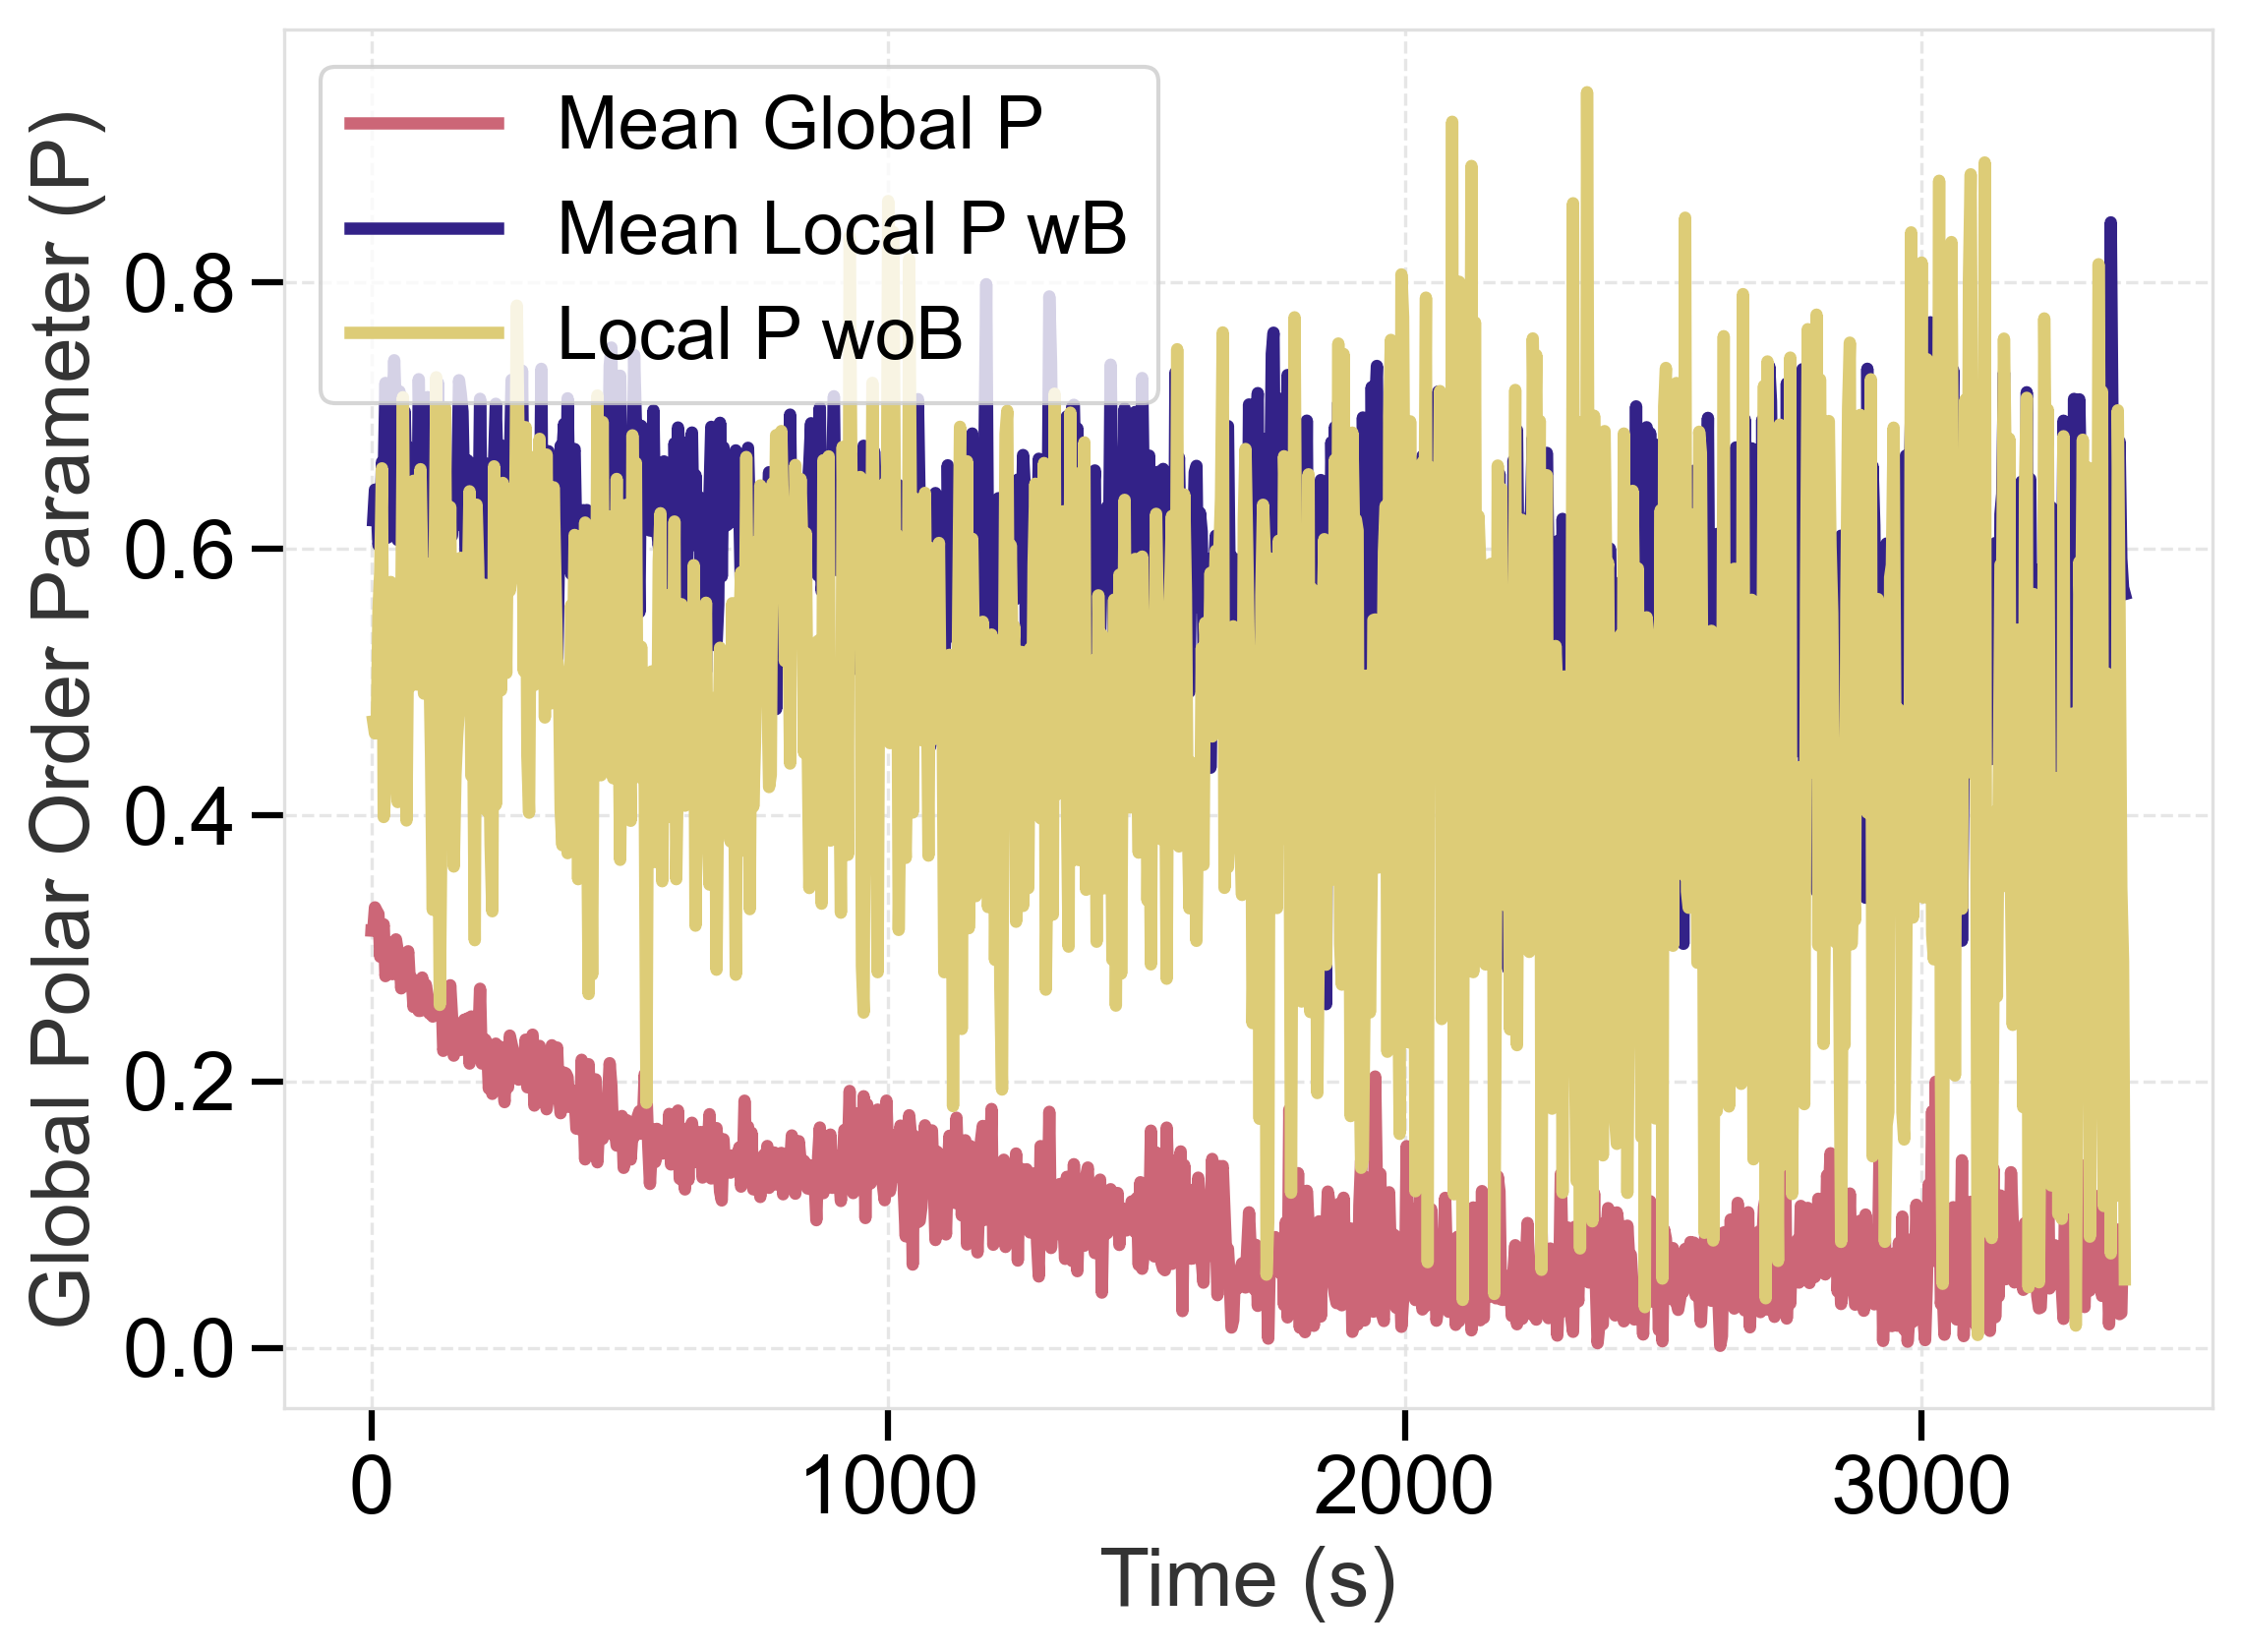

In [22]:
tau = 1.18

mean_GP = GP_df.groupby('t').mean().reset_index()
std_GP = GP_df.groupby('t').std().reset_index()
fig, ax = plt.subplots()
ax.plot(mean_GP['t']/tau, mean_GP['P'], label='Mean Global P')
#ax.fill_between(std_GP['t']/tau, mean_GP['P'] - std_GP['P'], mean_GP['P'] + std_GP['P'], alpha=0.5, label='±1 Std Dev')

mean_LP = LP_df.groupby('frame').mean()['local_P']
ax.plot(interval*mean_LP.index/tau, mean_LP, label='Mean Local P wB')

mean_LPwoB = LP_woB_df.groupby('frame').mean()['P']
ax.plot(interval*mean_LPwoB.index/tau, mean_LPwoB, label='Local P woB')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Global Polar Order Parameter (P)')
ax.legend()

In [15]:
LP_df.groupby('frame').mean()['local_P']

frame
0            NaN
1       0.621511
2       0.644509
3       0.633443
4       0.602762
          ...   
997     0.521869
998     0.680682
999     0.592651
1000    0.570966
1001    0.566046
Name: local_P, Length: 1002, dtype: float64

In [26]:
import numpy as np
import pandas as pd
import zarr
import os
import matplotlib.pyplot as plt

path = "/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp002"

track_path = os.path.join(path, "beads_tracks.csv")
tracks = pd.read_csv(track_path)
flow = os.path.join(path, "MTs_red_flow.zarr")
flow_array = zarr.open_array(flow, mode='r')

(0.0, 2160.0)

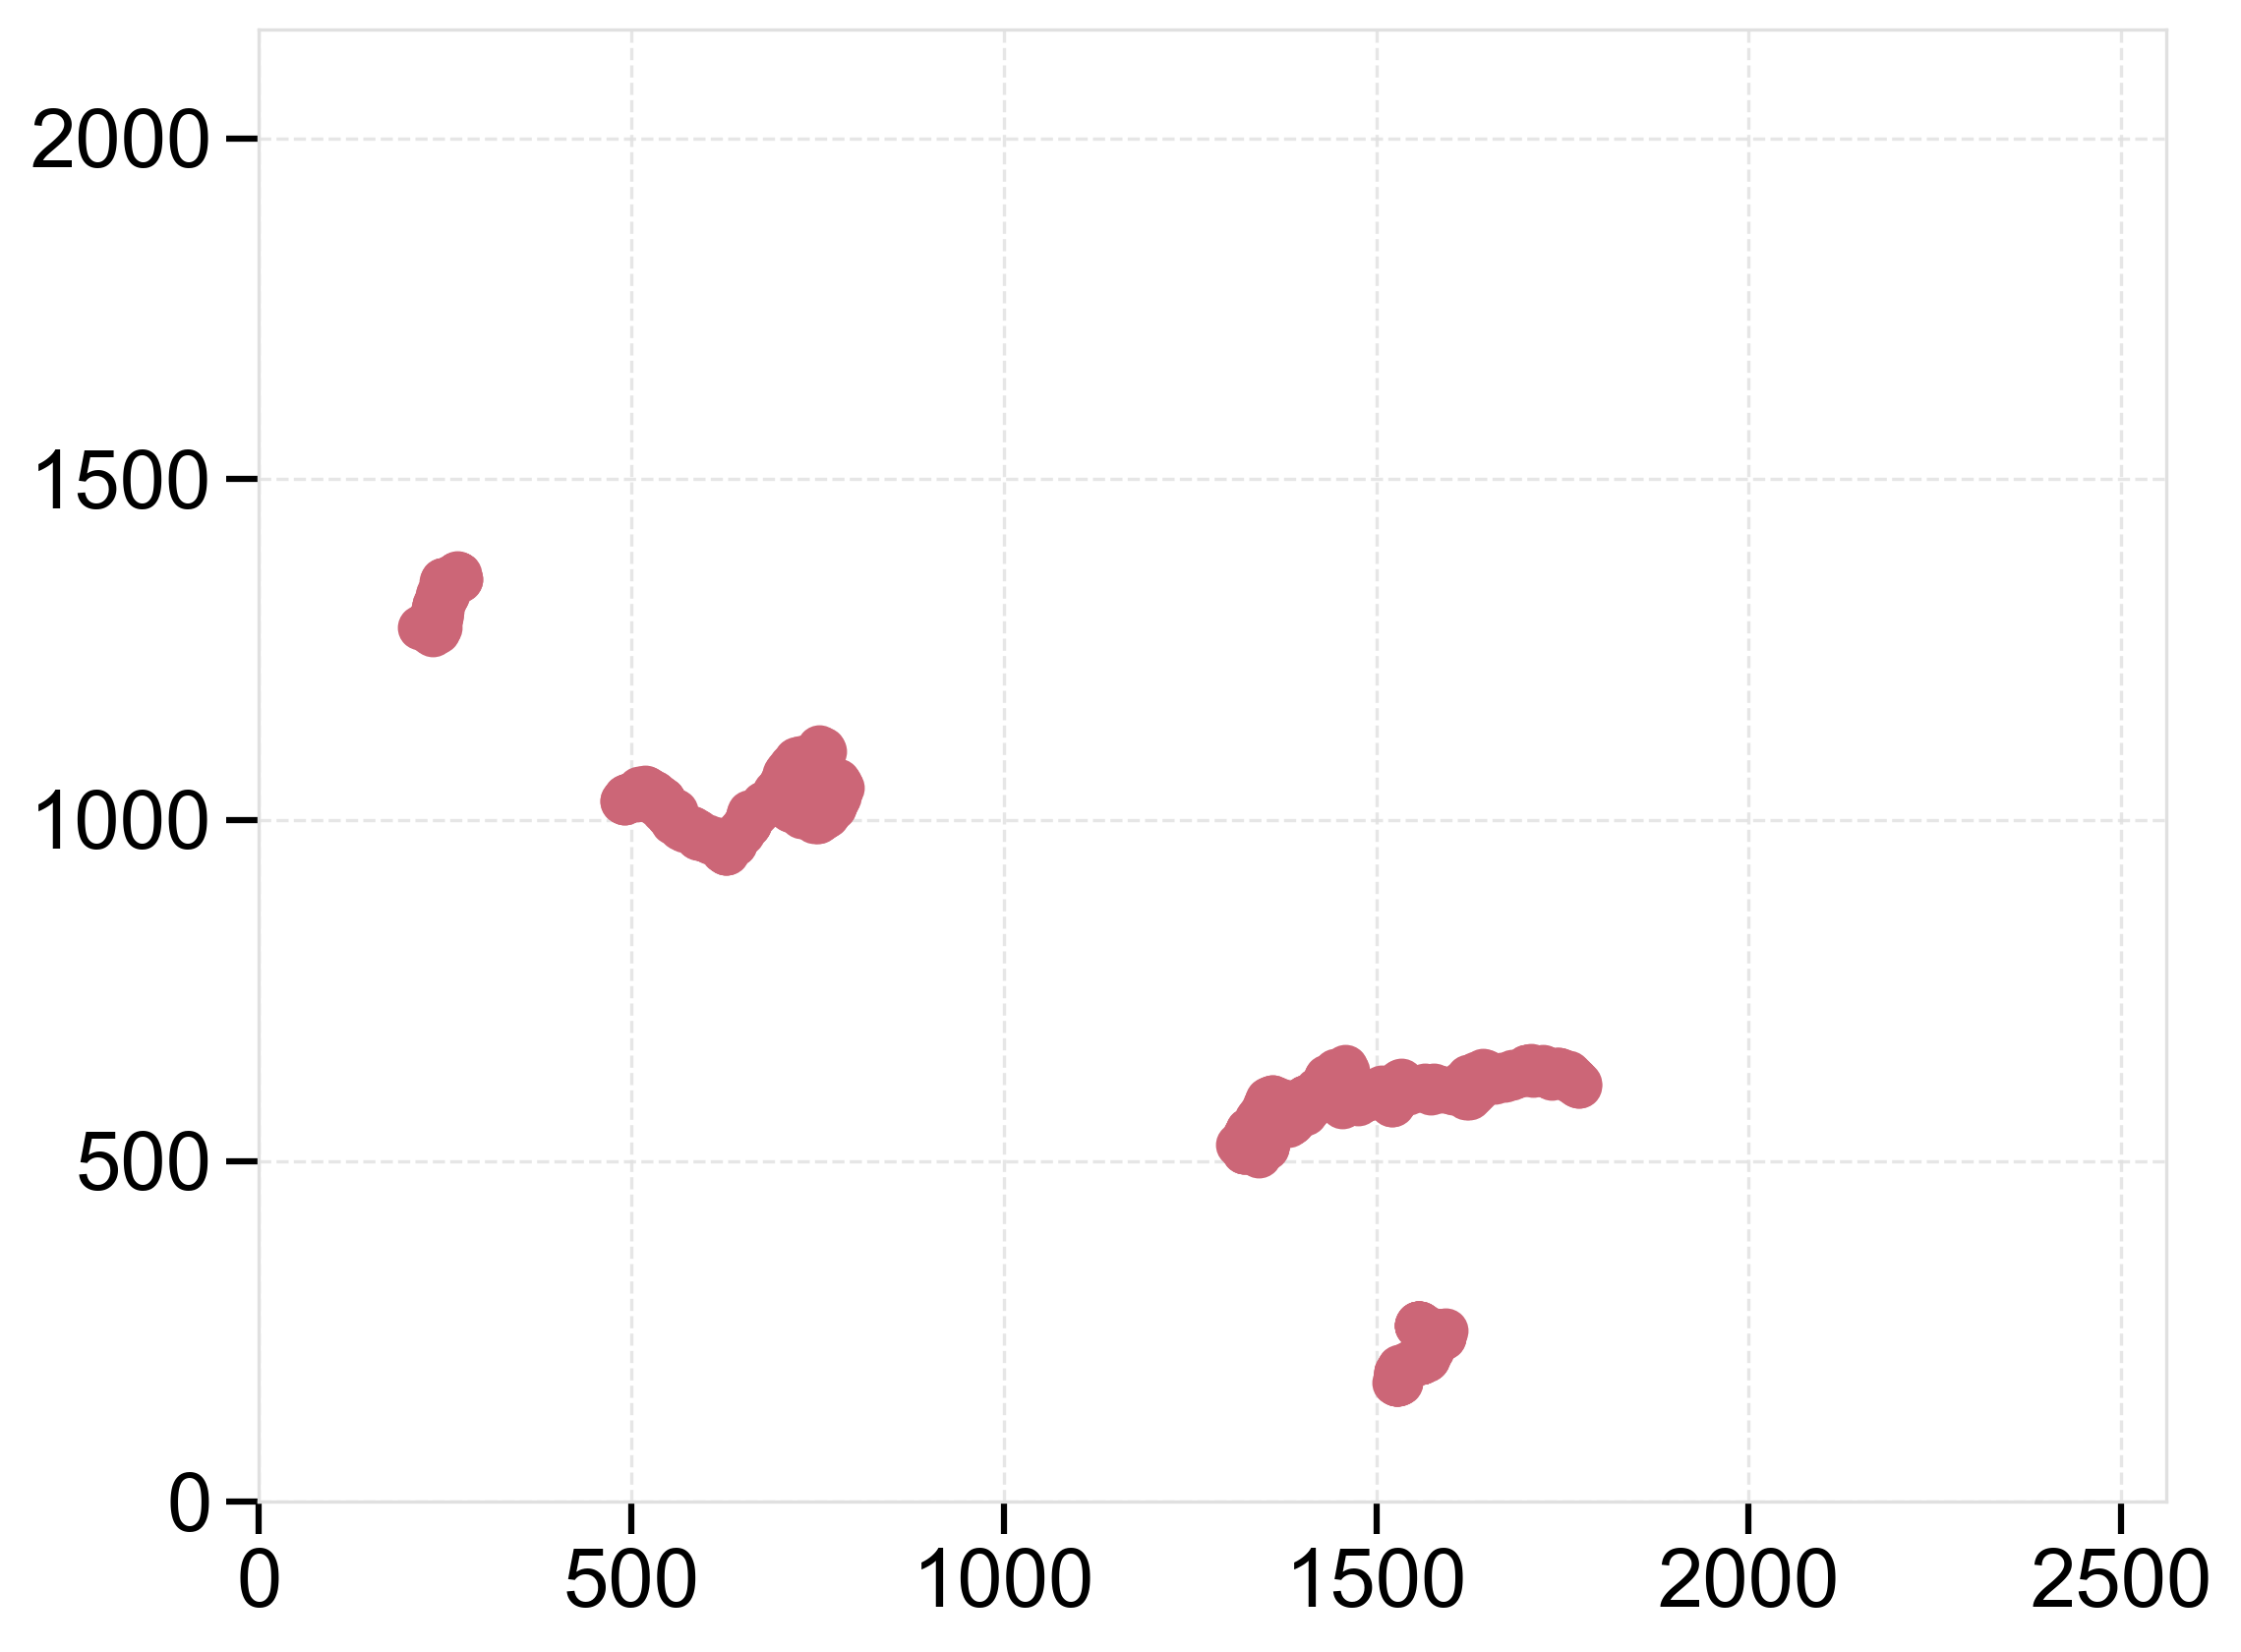

In [27]:
H = flow_array.shape[1]
W = flow_array.shape[2]

fig, ax = plt.subplots()
ax.scatter(tracks['x'], tracks['y'])

ax.set_xlim(0, W)
ax.set_ylim(0, H)

In [28]:
rectangle = 5
scale = 0.11

height = rectangle/scale
weight = rectangle/scale

x = 1500
y = 1500


def compute_local_P(flow_array, x, y, height, weight):
    # クロップ範囲計算
    h2 = int(height / 2)
    w2 = int(weight / 2)

    crop = flow_array[:, y-h2:y+h2, x-w2:x+w2]

    u = crop[:, :, :, 0]
    v = crop[:, :, :, 1]

    magnitude = np.sqrt(u**2 + v**2)
            
    # 平均計算
    mean_xf = np.mean(u, axis=(1, 2))
    mean_yf = np.mean(v, axis=(1, 2))
    mean_mag_vectors = np.mean(magnitude, axis=(1, 2))
    mag_mean_vector = np.sqrt(mean_xf**2 + mean_yf**2)

    # 計算結果を代入（ゼロ除算対策付き）
    with np.errstate(divide='ignore', invalid='ignore'):
        P_vals = mag_mean_vector / mean_mag_vectors

    return P_vals

P = compute_local_P(flow_array, x, y, height, weight)

(array([ 5., 18., 24., 36., 43., 51., 61., 52., 79., 62., 77., 77., 77.,
        66., 69., 55., 38., 37., 23., 10.]),
 array([0.00335203, 0.0495155 , 0.09567896, 0.14184242, 0.18800589,
        0.23416936, 0.28033283, 0.3264963 , 0.37265977, 0.41882324,
        0.46498671, 0.51115018, 0.55731362, 0.60347712, 0.64964056,
        0.69580406, 0.7419675 , 0.78813094, 0.83429444, 0.88045788,
        0.92662138]),
 <BarContainer object of 20 artists>)

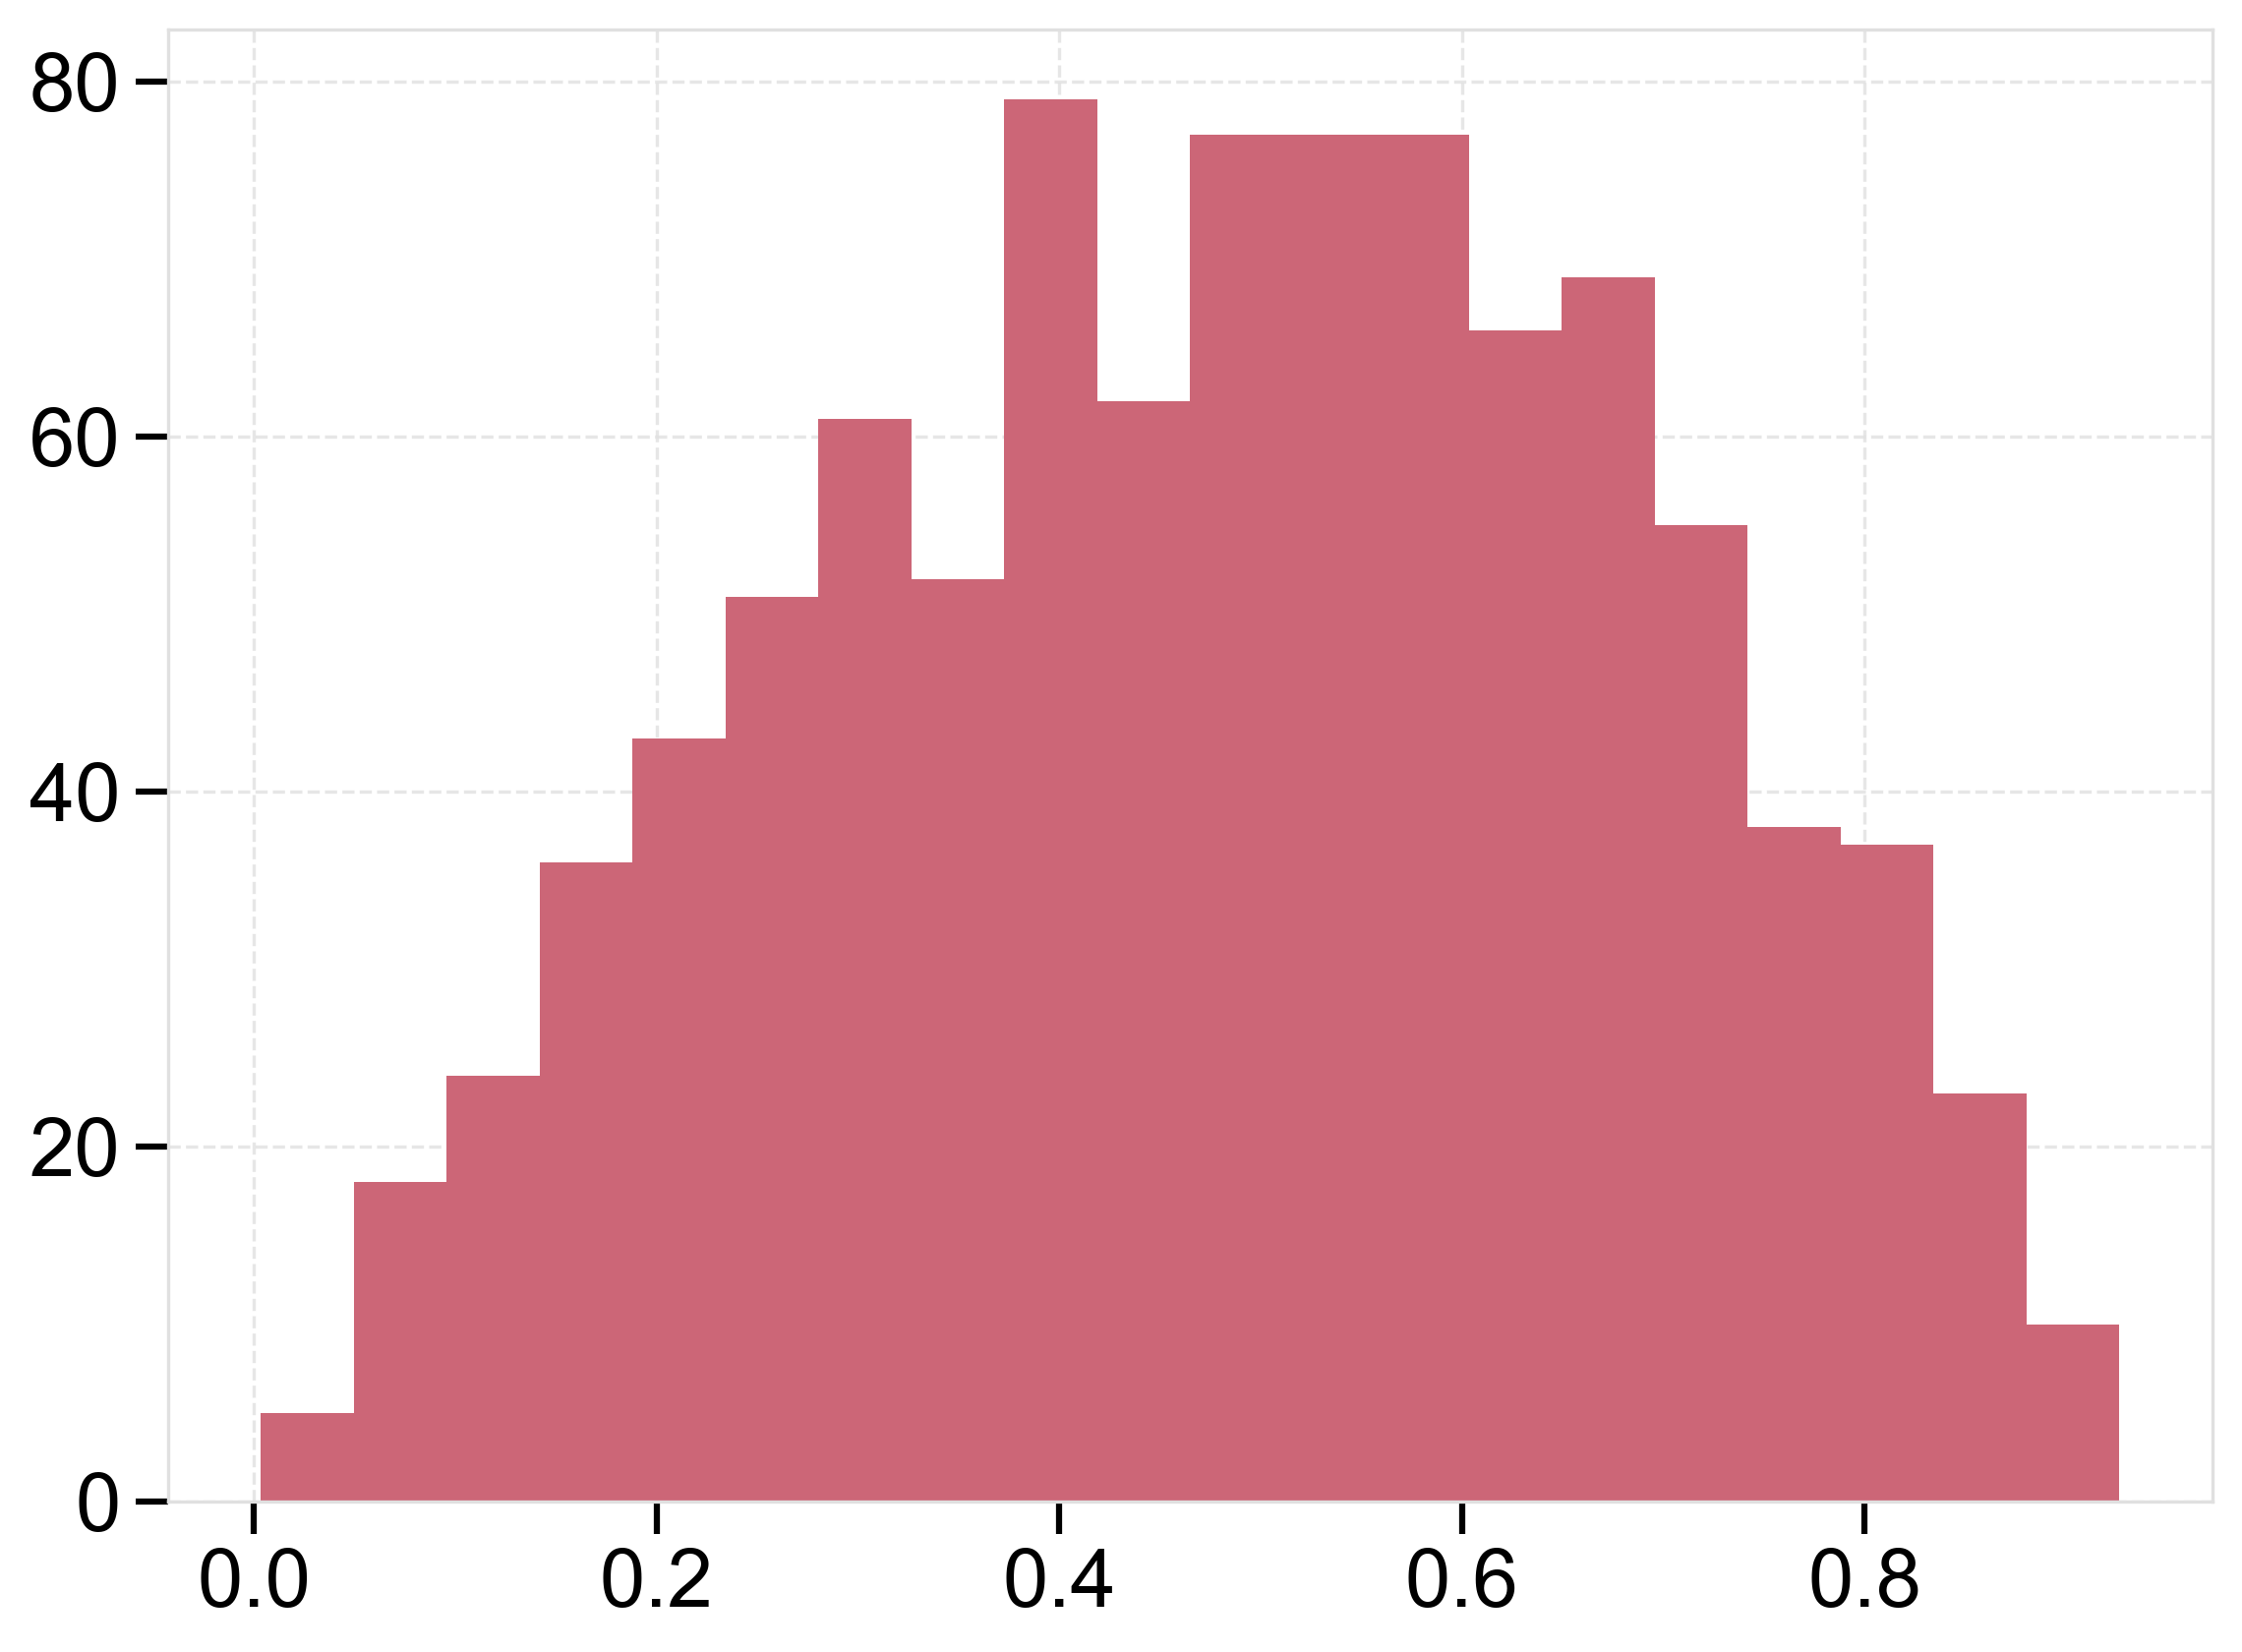

In [29]:
# Pの時間変化をプロット
fig, ax = plt.subplots()
ax.hist(P, bins=20)